# TEMPEST_RAD Retrieval Analysis

This notebook performs retrieval simulations and analysis using the TEMPEST_RAD simulator.
It covers:
1.  Running TEMPEST (if needed) to generate thermal models.
2.  Comparing Smooth vs. Rough Brightness Temperatures.
3.  Spectral Analysis of individual facets.
4.  Bolometric Phase Curve analysis.
5.  Simulating an Instrument Observation (Flux integration over FOV).

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
import shutil

# Ensure we can import from TEMPEST_RAD and src
# Adjust path to root directory relative to this notebook
current_dir = Path(os.getcwd()).resolve()
if current_dir.name == 'TEMPEST_RAD':
    root_dir = current_dir.parent
else:
    # Fallback if running from root
    root_dir = current_dir

# CHANGE WORKING DIRECTORY TO ROOT
# This ensures relative paths in config.yaml (like data/shape_models/...) work correctly
os.chdir(root_dir)
print(f"Working Directory set to: {os.getcwd()}")

sys.path.append(str(root_dir))

from src.utilities.config import Config
from src.utilities.utils import rotate_vector
from matplotlib.collections import PolyCollection
from TEMPEST_RAD.simulator import (
    load_shape_model, 
    compute_geometry, 
    RoughnessLUT, 
    planck_function, 
    rms_to_fraction, 
    calculate_theta
)

Working Directory set to: /Users/duncan/Desktop/DPhil/TEMPEST


## 1. Setup & Run TEMPEST

Define paths and run the core thermal model to generate surface temperatures.

In [2]:
# Define paths
CONFIG_PATH = os.path.join(root_dir, "private/data/config/moon/moon_config.yaml")
OUTPUT_DIR = os.path.join(root_dir, "output/retrieval_analysis")
LUT_PATH = os.path.join(root_dir, "roughness_lut_spectral_v1.h5")

print(f"--- Step 1: Running TEMPEST Simulation ---")
print(f"Config: {CONFIG_PATH}")
print(f"Output: {OUTPUT_DIR}")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Load Config and Shape Model FIRST to know what we expect
config = Config(CONFIG_PATH)
facets_expected, _ = load_shape_model(config.path_to_shape_model_file)
n_facets_expected = len(facets_expected)
print(f"Current Configuration expects {n_facets_expected} facets.")

# Find latest run
def get_latest_run_dir():
    base_out = os.path.join(root_dir, "output")
    if not os.path.exists(base_out): return None
    runs = [os.path.join(base_out, d) for d in os.listdir(base_out) if d.startswith("run_")]
    if not runs: return None
    return max(runs, key=os.path.getmtime)

print("Checking for existing TEMPEST runs...")
latest_run = get_latest_run_dir()
run_needed = True

if latest_run:
    temp_file = os.path.join(latest_run, "temperatures.csv")
    if os.path.exists(temp_file):
        # Check dimensions to ensure it matches current shape model
        try:
            # Load full file to check shape (safer than heuristic)
            temp_data = np.loadtxt(temp_file, delimiter=',')
            
            # Check if dimensions match n_facets_expected
            # TEMPEST output is usually (N_facets, N_timesteps) or transposed
            rows = temp_data.shape[0]
            cols = temp_data.shape[1] if len(temp_data.shape) > 1 else 1
            
            if rows == n_facets_expected or cols == n_facets_expected:
                print(f"Found compatible existing run: {latest_run}")
                shutil.copy(temp_file, os.path.join(OUTPUT_DIR, "temperatures.csv"))
                run_needed = False
            else:
                print(f"Existing run {latest_run} has shape {temp_data.shape}, but expected {n_facets_expected} facets. Re-running.")
        except Exception as e:
            print(f"Error checking existing run: {e}. Re-running.")
    else:
         print(f"Run folder {latest_run} found but no temperatures.csv. Re-running.")

if run_needed:
    print("Running TEMPEST... (this may take a moment)")
    cmd = ["python", "tempest.py", "--config", CONFIG_PATH]
    subprocess.run(cmd, check=True)
    
    # Get the new latest run
    latest_run = get_latest_run_dir()
    print(f"New run created at: {latest_run}")
    shutil.copy(os.path.join(latest_run, "temperatures.csv"), os.path.join(OUTPUT_DIR, "temperatures.csv"))


--- Step 1: Running TEMPEST Simulation ---
Config: /Users/duncan/Desktop/DPhil/TEMPEST/private/data/config/moon/moon_config.yaml
Output: /Users/duncan/Desktop/DPhil/TEMPEST/output/retrieval_analysis
Current Configuration expects 1280 facets.
Checking for existing TEMPEST runs...
Found compatible existing run: /Users/duncan/Desktop/DPhil/TEMPEST/output/run_2026-02-17_11-43-51


## 2. Load Data

Load the shape model, temperatures, and the Roughness Lookup Table (LUT).

In [3]:
print(f"--- Step 2: Loading Data ---")
config = Config(CONFIG_PATH)
facets, mesh = load_shape_model(config.path_to_shape_model_file)
n_facets = len(facets)

# Load Temperatures
temps_path = os.path.join(OUTPUT_DIR, "temperatures.csv")
try:
    temps_all = np.loadtxt(temps_path, delimiter=',')
except ValueError:
    temps_all = np.loadtxt(temps_path, delimiter=',', skiprows=1)

# Handle Transpose if needed
if temps_all.shape[0] != n_facets and temps_all.shape[1] == n_facets:
    temps_all = temps_all.T

print(f"Loaded temperatures: {temps_all.shape}")

# Load LUT
theta = calculate_theta(config)
print(f"Calculated Theta: {theta:.3f}")
lut = RoughnessLUT(LUT_PATH, target_theta=theta, target_rms=90.0) # Load spectral LUT

# Helper to get temps at a specific time
def get_temps_at_time(time_hours):
    period = getattr(config, 'rotation_period_hours', 24.0)
    n_steps = temps_all.shape[1]
    idx = int((time_hours % period) / period * n_steps)
    idx = np.clip(idx, 0, n_steps - 1)
    return temps_all[:, idx]

--- Step 2: Loading Data ---
Loaded temperatures: (1280, 360)
Calculated Theta: 0.028
LUT: Selected Theta=0.0316 (Target=0.02762983430898598)
LUT: Using 'opening_angle' axis.
LUT: Selected Angle=90.0 (Target=90.0)


## 3. Analysis: Brightness Temp Maps

Compare Smooth vs. Rough bolometric brightness temperature maps for a specific time and phase.

--- Step 3: Generating Brightness Temperature Maps ---

PHASE ANGLE: 0° (Time=12.0h)

=== DEBUG: Disk Center Facet (idx=0) ===
  Emission: 0.00°
  Sun Phase: 6.10°
  Latitude: 86.30°
  Azimuth: 0.00°
  Temperature: 152.62 K
  Mixing fraction f: 0.100

  Wavelength | Smooth Rad | Factor | Rough Rad | Change
  ------------------------------------------------------------
     5.0 um |  2.298e-04 | 0.143  |  2.259e-04 |  -1.71%
     8.0 um |  2.588e-02 | 0.177  |  2.544e-02 |  -1.71%
    15.0 um |  2.782e-01 | 0.332  |  2.734e-01 |  -1.71%
    50.0 um |  6.820e-02 | 0.831  |  6.704e-02 |  -1.71%
   100.0 um |  7.601e-03 | 0.829  |  7.472e-03 |  -1.71%

  Bolometric Tb: 149.04 K
  Mean visible Tb: 2.68e+02
Visible facets: 640/1280
Smooth: 330.5 K | Rough: 330.6 K | Diff: +0.06 K
  Equatorial (<30°): +0.76 K | Polar (≥60°): -2.07 K

PHASE ANGLE: 10° (Time=12.0h)
Visible facets: 640/1280
Smooth: 325.7 K | Rough: 325.8 K | Diff: +0.10 K
  Equatorial (<30°): +0.76 K | Polar (≥60°): -1.76 K

PHA

/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/189576059.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)
/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/189576059.py:60: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol_center = np.trapz(full_spectra[center_idx, :], x=wavelengths)
/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/189576059.py:64: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  Mean visible Tb: {np.mean(np.trapz(full_spectra[visible, :], x=wavelengths, axis=1)):.2e}")


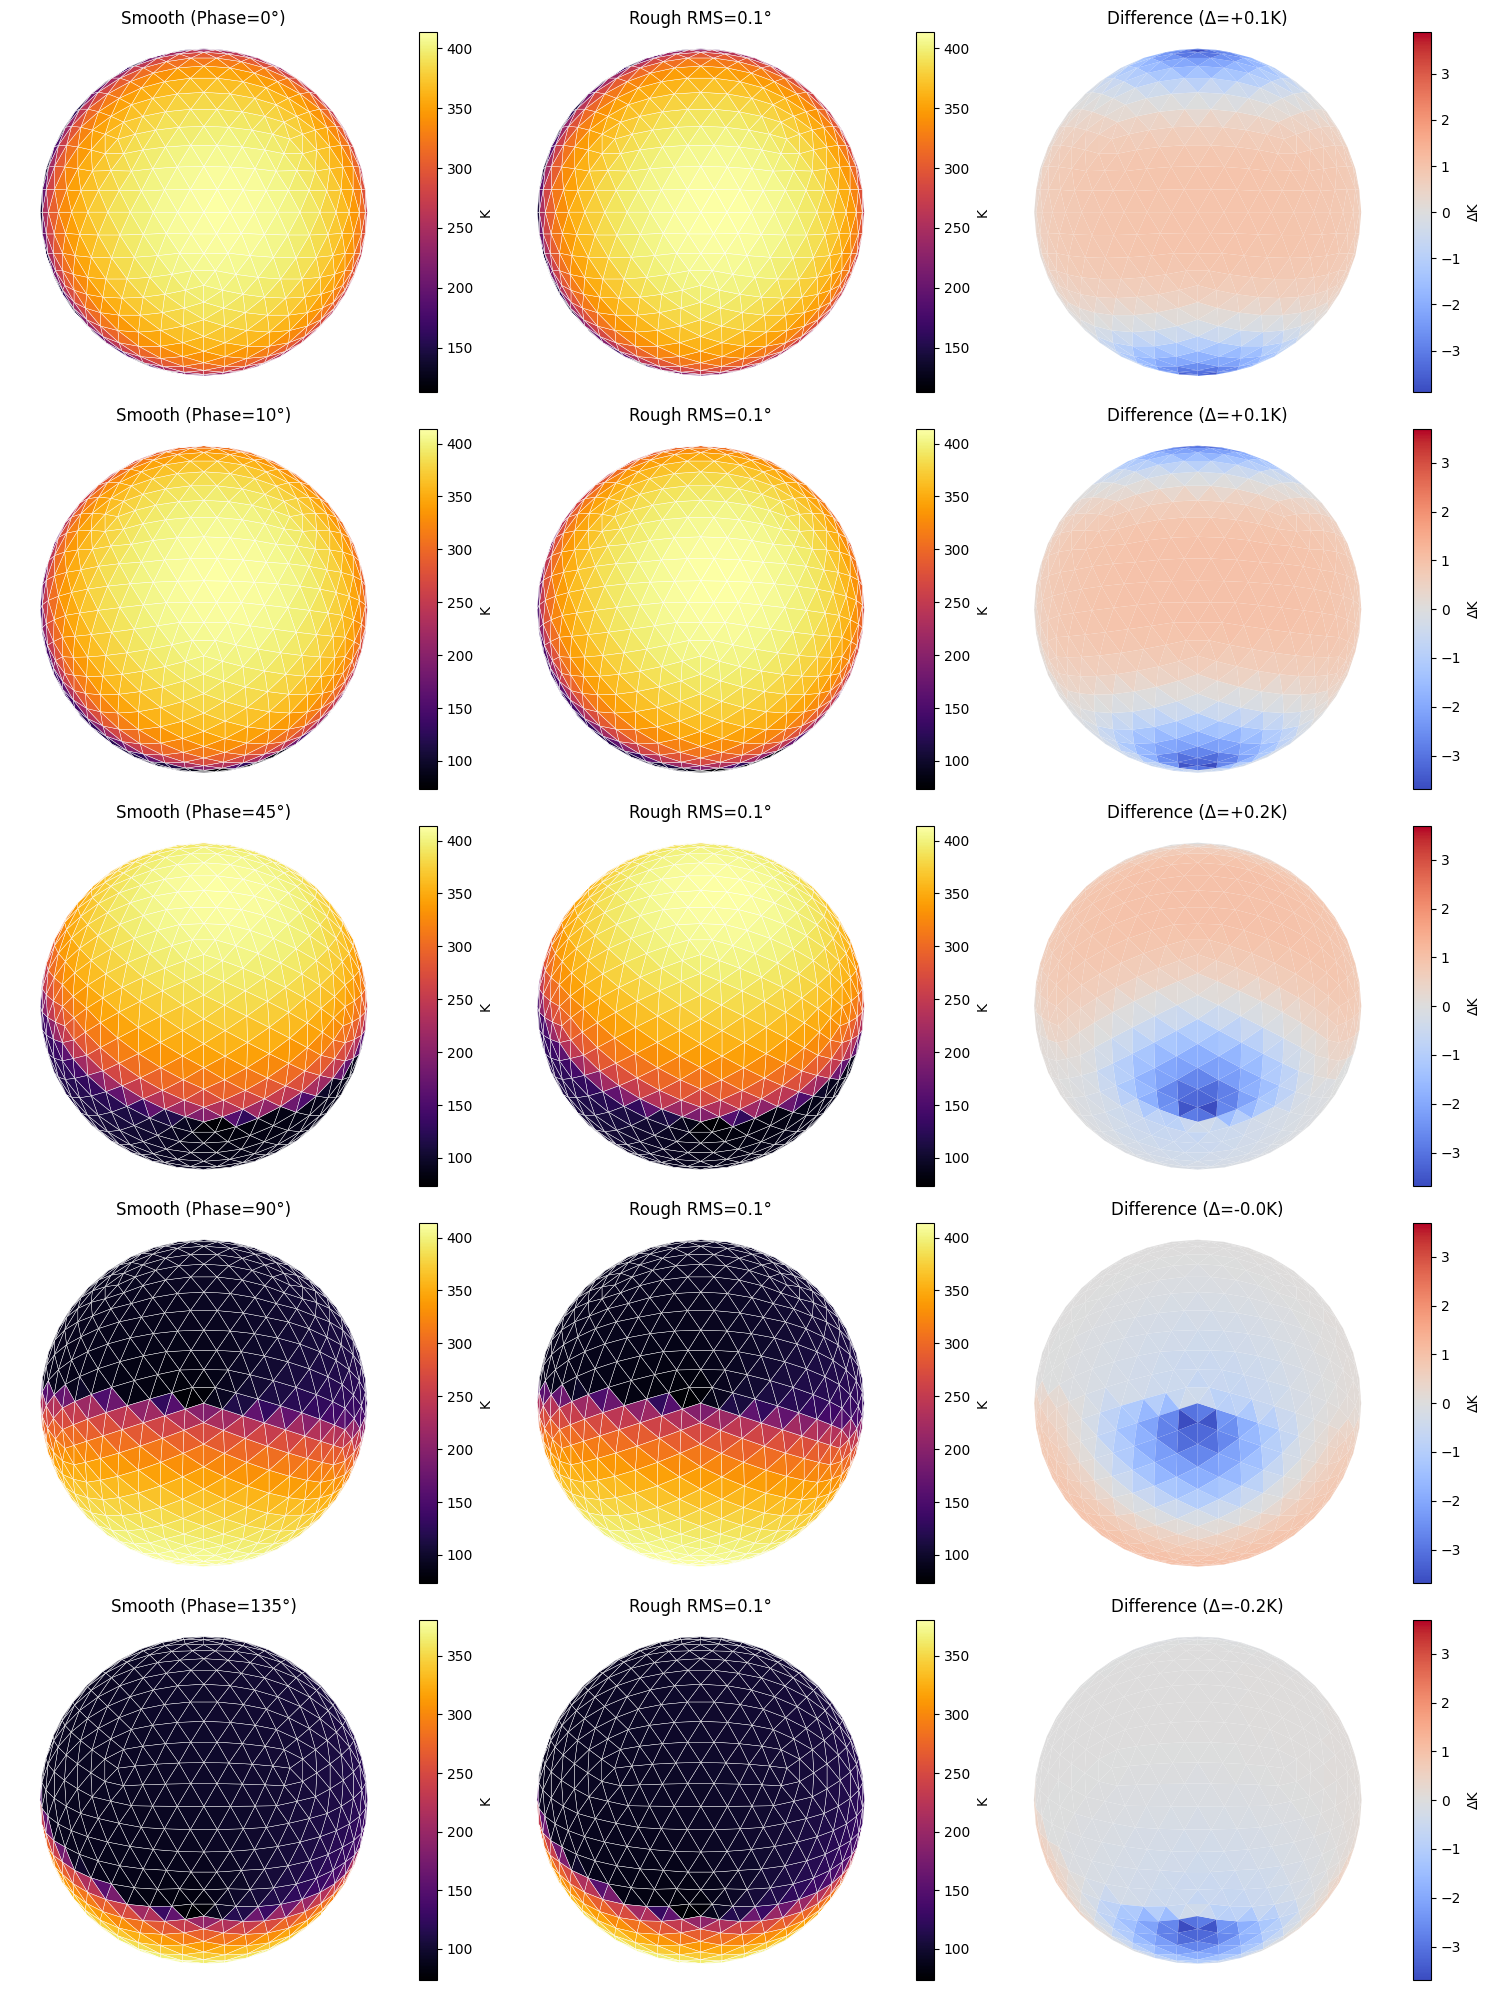

In [4]:
print(f"--- Step 3: Generating Brightness Temperature Maps ---")

def calculate_bolometric_tb(time_hours, roughness_rms, phase_angle, debug=False):
    # Geometry
    sun_vec = np.array(config.sunlight_direction)
    rot_axis = np.array([0, 0, 1]) # Simplified
    
    # Observer Vector
    perp_vec = np.cross(sun_vec, rot_axis)
    if np.linalg.norm(perp_vec) < 1e-6: perp_vec = np.array([0, 1, 0])
    obs_vec = rotate_vector(sun_vec, perp_vec, np.radians(phase_angle))
    
    lats, phases, emis, azis = compute_geometry(facets, sun_vec, obs_vec, rot_axis)
    
    # *** FIX: Override per-facet local times with global body rotation phase ***
    # The LUT expects a single rotation phase for the entire body, not per-facet local times
    period = getattr(config, 'rotation_period_hours', 24.0)
    body_rotation_phase = (time_hours / period * 360.0) % 360.0
    phases = np.full_like(phases, body_rotation_phase)  # Same phase for all facets
    
    # Temps
    temps_smooth = get_temps_at_time(time_hours)
    
    # Roughness
    f = rms_to_fraction(roughness_rms)
    
    # Wavelength Loop
    wavelengths = lut.axes['wavelength']
    full_spectra = np.zeros((n_facets, len(wavelengths)))
    
    for i, wave in enumerate(wavelengths):
        rad_smooth = planck_function(wave, temps_smooth)
        factors = lut.get_correction_factors(lats, phases, emis, azis, wavelength=wave)
        full_spectra[:, i] = rad_smooth * ((1.0 - f) + f * factors)
        
    # DEBUG OUTPUT
    if debug and roughness_rms > 0:
        # Find disk center facet (lowest emission angle)
        center_idx = np.argmin(emis)
        print(f"\n=== DEBUG: Disk Center Facet (idx={center_idx}) ===")
        print(f"  Emission: {emis[center_idx]:.2f}°")
        print(f"  Sun Phase: {phases[center_idx]:.2f}°")
        print(f"  Latitude: {lats[center_idx]:.2f}°")
        print(f"  Azimuth: {azis[center_idx]:.2f}°")
        print(f"  Temperature: {temps_smooth[center_idx]:.2f} K")
        print(f"  Mixing fraction f: {f:.3f}")
        print(f"\n  Wavelength | Smooth Rad | Factor | Rough Rad | Change")
        print(f"  " + "-"*60)
        for i, wave in enumerate(wavelengths):
            rad_s = full_spectra[center_idx, i] / ((1.0 - f) + f * factors[center_idx])  # Back-calculate smooth
            rad_r = full_spectra[center_idx, i]
            factor = factors[center_idx]
            # Get the actual factor used
            factors_wave = lut.get_correction_factors(lats, phases, emis, azis, wavelength=wave)
            change = ((rad_r / rad_s) - 1.0) * 100 if rad_s > 0 else 0
            print(f"  {wave:6.1f} um | {rad_s:10.3e} | {factors_wave[center_idx]:.3f}  | {rad_r:10.3e} | {change:+6.2f}%")
        
        # Bolometric
        visible = emis < 90
        rad_bol_center = np.trapz(full_spectra[center_idx, :], x=wavelengths)
        sigma = 5.670374419e-8
        t_eff_center = (np.pi * rad_bol_center / sigma) ** 0.25
        print(f"\n  Bolometric Tb: {t_eff_center:.2f} K")
        print(f"  Mean visible Tb: {np.mean(np.trapz(full_spectra[visible, :], x=wavelengths, axis=1)):.2e}")
        
    # Integrate
    rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)
    sigma = 5.670374419e-8
    t_eff = (np.pi * rad_bol / sigma) ** 0.25
    
    # Mask hidden
    t_eff[emis > 90] = 0
    
    return t_eff, obs_vec, emis

# Compare at multiple phase angles
time_tgt = 12.0
roughness_rms = 0.1
phase_angles_to_plot = [0, 10, 45, 90, 135]  # Forward scattering and backscattering

# Projection helper
def project_polys(obs_vec, mesh_vectors):
    obs_n = obs_vec / np.linalg.norm(obs_vec)
    up = np.array([0, 0, 1])
    if abs(np.dot(up, obs_n)) > 0.9: up = np.array([1, 0, 0])
    u = np.cross(obs_n, up); u /= np.linalg.norm(u)
    v = np.cross(obs_n, u)
    
    # Project vertices (N, 3, 3)
    u_verts = np.dot(mesh_vectors, u)
    v_verts = np.dot(mesh_vectors, v)
    return np.stack((u_verts, v_verts), axis=2)

# Create figure with subplots for each phase angle
n_phases = len(phase_angles_to_plot)
fig, axes = plt.subplots(n_phases, 3, figsize=(15, 4*n_phases))
if n_phases == 1:
    axes = axes.reshape(1, -1)

for row_idx, phase_tgt in enumerate(phase_angles_to_plot):
    print(f"\n{'='*70}")
    print(f"PHASE ANGLE: {phase_tgt}° (Time={time_tgt}h)")
    print(f"{'='*70}")
    
    tb_smooth, obs_vec, emis = calculate_bolometric_tb(time_tgt, 0.0, phase_tgt, debug=False)
    tb_rough, _, _ = calculate_bolometric_tb(time_tgt, roughness_rms, phase_tgt, debug=(phase_tgt==0))
    
    # Summary Statistics
    visible = emis < 90
    mean_s = np.mean(tb_smooth[visible])
    mean_r = np.mean(tb_rough[visible])
    
    print(f"Visible facets: {np.sum(visible)}/{len(facets)}")
    print(f"Smooth: {mean_s:.1f} K | Rough: {mean_r:.1f} K | Diff: {mean_r - mean_s:+.2f} K")
    
    # Check for latitude bias in diff
    lats_temp, _, emis_temp, _ = compute_geometry(facets, np.array(config.sunlight_direction), obs_vec, np.array([0,0,1]))
    equatorial = (np.abs(lats_temp) < 30) & visible
    polar = (np.abs(lats_temp) >= 60) & visible
    
    if np.sum(equatorial) > 0 and np.sum(polar) > 0:
        diff_eq = np.mean(tb_rough[equatorial]) - np.mean(tb_smooth[equatorial])
        diff_polar = np.mean(tb_rough[polar]) - np.mean(tb_smooth[polar])
        print(f"  Equatorial (<30°): {diff_eq:+.2f} K | Polar (≥60°): {diff_polar:+.2f} K")
    
    # Plot
    polys = project_polys(obs_vec, mesh.vectors)
    mask = visible
    
    # Global colorbar limits for consistency
    vmin_tb = min(np.min(tb_smooth[mask]), np.min(tb_rough[mask]))
    vmax_tb = max(np.max(tb_smooth[mask]), np.max(tb_rough[mask]))
    
    # Smooth
    coll1 = PolyCollection(polys[mask], array=tb_smooth[mask], cmap='inferno', edgecolors='white', linewidths=0.3)
    coll1.set_clim(vmin_tb, vmax_tb)
    axes[row_idx, 0].add_collection(coll1)
    axes[row_idx, 0].set_title(f"Smooth (Phase={phase_tgt}°)")
    axes[row_idx, 0].autoscale()
    axes[row_idx, 0].axis('equal')
    axes[row_idx, 0].axis('off')
    plt.colorbar(coll1, ax=axes[row_idx, 0], label="K", fraction=0.046)
    
    # Rough
    coll2 = PolyCollection(polys[mask], array=tb_rough[mask], cmap='inferno', edgecolors='white', linewidths=0.3)
    coll2.set_clim(vmin_tb, vmax_tb)
    axes[row_idx, 1].add_collection(coll2)
    axes[row_idx, 1].set_title(f"Rough RMS={roughness_rms}°")
    axes[row_idx, 1].autoscale()
    axes[row_idx, 1].axis('equal')
    axes[row_idx, 1].axis('off')
    plt.colorbar(coll2, ax=axes[row_idx, 1], label="K", fraction=0.046)
    
    # Difference
    diff = tb_rough - tb_smooth
    vmax_diff = max(1.0, np.max(np.abs(diff[mask])))  # At least ±1K range
    coll3 = PolyCollection(polys[mask], array=diff[mask], cmap='coolwarm', edgecolors='face', linewidths=0.0)
    coll3.set_clim(-vmax_diff, vmax_diff)
    axes[row_idx, 2].add_collection(coll3)
    axes[row_idx, 2].set_title(f"Difference (Δ={mean_r-mean_s:+.1f}K)")
    axes[row_idx, 2].autoscale()
    axes[row_idx, 2].axis('equal')
    axes[row_idx, 2].axis('off')
    plt.colorbar(coll3, ax=axes[row_idx, 2], label="ΔK", fraction=0.046)

plt.tight_layout()
plt.show()

## 4. Analysis: Spectral Comparison

Examine the spectral radiance for a single facet (e.g., sub-solar) to see deviations from a Planck function.

--- Step 4: Spectral Analysis ---
Selected Facet 917 (Sub-solar alignment: 0.996)


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/153495597.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol_smooth = np.trapz(spec_smooth, x=wavelengths)
/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/153495597.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol_rough = np.trapz(spec_rough, x=wavelengths)


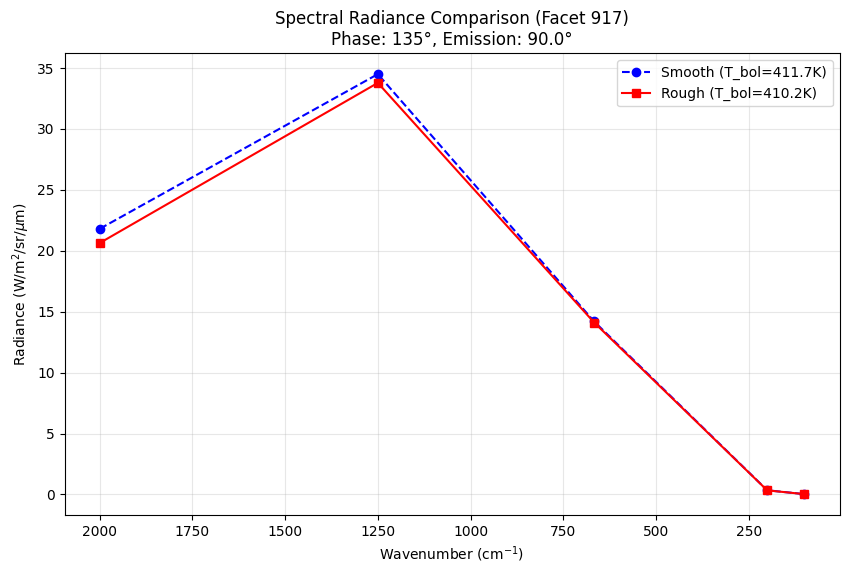

In [5]:
print(f"--- Step 4: Spectral Analysis ---")

# Pick a warm facet (e.g., closest to sub-solar point)
sun_vec = np.array(config.sunlight_direction)
centers = np.array([f.center for f in facets])
dots = np.dot(centers / np.linalg.norm(centers, axis=1)[:, None], sun_vec / np.linalg.norm(sun_vec))
target_facet_idx = np.argmax(dots)

print(f"Selected Facet {target_facet_idx} (Sub-solar alignment: {dots[target_facet_idx]:.3f})")

# Calculate Spectra
wavelengths = lut.axes['wavelength']
temps_smooth_val = get_temps_at_time(time_tgt)[target_facet_idx]

# Smooth Spectrum (Planck)
spec_smooth = planck_function(wavelengths, temps_smooth_val)

# Rough Spectrum
# Need geometry for this specific facet
lats, phases, emis, azis = compute_geometry([facets[target_facet_idx]], sun_vec, obs_vec, np.array([0,0,1]))
f = rms_to_fraction(28.0)

spec_rough = np.zeros_like(spec_smooth)
for i, wave in enumerate(wavelengths):
    rad_s = planck_function(wave, temps_smooth_val)
    factor = lut.get_correction_factors(lats, phases, emis, azis, wavelength=wave)[0]
    spec_rough[i] = rad_s * ((1.0 - f) + f * factor)

# Calculate Bolometric Temps
rad_bol_smooth = np.trapz(spec_smooth, x=wavelengths)
sigma = 5.670374419e-8
t_eff_smooth = (np.pi * rad_bol_smooth / sigma) ** 0.25

rad_bol_rough = np.trapz(spec_rough, x=wavelengths)
t_eff_rough = (np.pi * rad_bol_rough / sigma) ** 0.25

# Convert to Wavenumber
wavenumbers = 10000.0 / wavelengths # cm^-1

# Plot
plt.figure(figsize=(10, 6))
plt.plot(wavenumbers, spec_smooth, 'o--', label=f'Smooth (T_bol={t_eff_smooth:.1f}K)', color='blue')
plt.plot(wavenumbers, spec_rough, 's-', label=f'Rough (T_bol={t_eff_rough:.1f}K)', color='red')

plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Radiance (W/m$^2$/sr/$\\mu$m)")
plt.title(f"Spectral Radiance Comparison (Facet {target_facet_idx})\nPhase: {phase_tgt}°, Emission: {emis[0]:.1f}°")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()
plt.show()

## 5. Analysis: Phase Curve Variation

Calculate the mean disk brightness temperature across varied phase angles.

--- Step 5: Phase Curve Analysis ---


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/189576059.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)


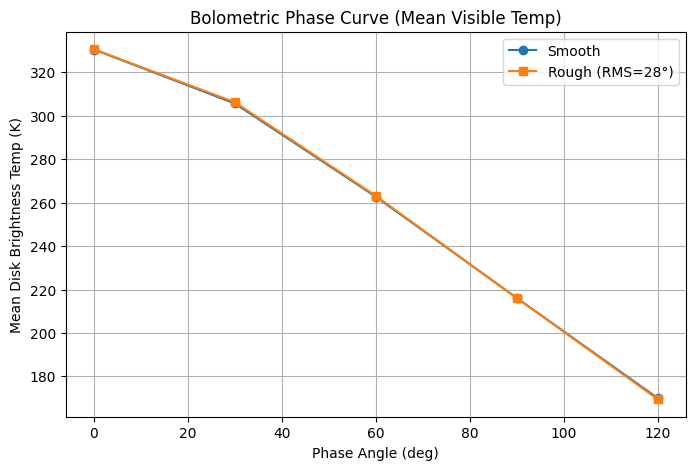

In [6]:
print(f"--- Step 5: Phase Curve Analysis ---")

phases_to_test = [0, 30, 60, 90, 120]
mean_temps_smooth = []
mean_temps_rough = []

for p in phases_to_test:
    # Calculate maps
    tb_s, _, emi_s = calculate_bolometric_tb(time_tgt, 0.0, p)
    tb_r, _, emi_r = calculate_bolometric_tb(time_tgt, 28.0, p)
    
    # Average over visible disk (simple mean for now, ideally area-weighted)
    mask_s = emi_s < 90
    mask_r = emi_r < 90
    
    mean_temps_smooth.append(np.mean(tb_s[mask_s]))
    mean_temps_rough.append(np.mean(tb_r[mask_r]))

plt.figure(figsize=(8, 5))
plt.plot(phases_to_test, mean_temps_smooth, 'o-', label='Smooth')
plt.plot(phases_to_test, mean_temps_rough, 's-', label='Rough (RMS=28°)')
plt.xlabel("Phase Angle (deg)")
plt.ylabel("Mean Disk Brightness Temp (K)")
plt.title("Bolometric Phase Curve (Mean Visible Temp)")
plt.legend()
plt.grid(True)
plt.show()

## 6. Simulated Instrument Observation (FOV)

Simulate a spacecraft instrument with a specific Field of View (FOV) and distance, integrating the flux from all visible facets within that FOV.

--- Step 6: Simulated Instrument Observation ---
Instrument FOV: 5.0° at 2000.0km
Facets in FOV and Visible: 640


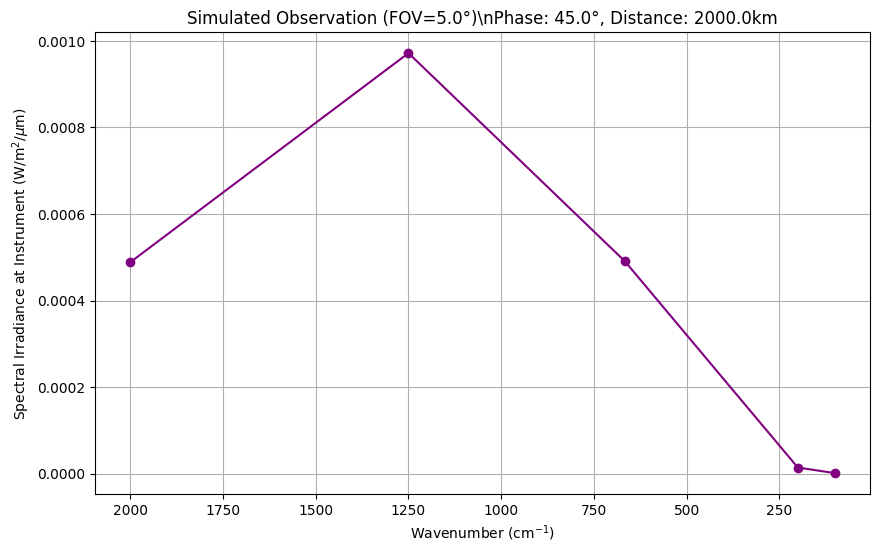


--- Analysis Complete ---


In [7]:
print(f"--- Step 6: Simulated Instrument Observation ---")

# Define Instrument
inst_dist = 2000.0 # km
inst_phase = 45.0
fov_deg = 5.0 # Narrow FOV

# Calculate Position
sun_vec = np.array(config.sunlight_direction)
rot_axis = np.array([0, 0, 1])
perp_vec = np.cross(sun_vec, rot_axis)
if np.linalg.norm(perp_vec) < 1e-6: perp_vec = np.array([0, 1, 0])
obs_dir = rotate_vector(sun_vec, perp_vec, np.radians(inst_phase))
obs_dir /= np.linalg.norm(obs_dir)
inst_pos = obs_dir * inst_dist * 1000 # meters

# Boresight (looking at center)
boresight = -obs_dir

# Find facets in FOV
centers = np.array([f.center for f in facets]) # meters
vecs_to_facets = centers - inst_pos # Vector from Inst to Facet
dists = np.linalg.norm(vecs_to_facets, axis=1)
vecs_norm = vecs_to_facets / dists[:, None]

# Angle from boresight
# dot(v, boresight) = cos(theta)
cos_thetas = np.dot(vecs_norm, boresight)
thetas = np.degrees(np.arccos(np.clip(cos_thetas, -1.0, 1.0)))

in_fov = (thetas < (fov_deg / 2.0))

# Check visibility (Emission < 90)
# Need normal vectors
normals = np.array([f.normal for f in facets])
# View vector is -vecs_norm (Facet to Inst)
cos_emis = np.einsum('ij,ij->i', normals, -vecs_norm)
visible = cos_emis > 0

valid_mask = in_fov & visible
valid_indices = np.where(valid_mask)[0]

print(f"Instrument FOV: {fov_deg}° at {inst_dist}km")
print(f"Facets in FOV and Visible: {len(valid_indices)}")

if len(valid_indices) > 0:
    # Integrate Spectrum
    # Flux Density = Sum ( Radiance * Solid_Angle )
    # Solid Angle = Area * cos(emi) / dist^2
    
    areas = np.array([f.area for f in facets])[valid_mask]
    dists_sq = dists[valid_mask]**2
    cos_e = cos_emis[valid_mask]
    solid_angles = areas * cos_e / dists_sq
    
    # Get Rough Radiance for these facets
    # Re-use logic (simplified for this block)
    lats, phases, emis, azis = compute_geometry(
        [facets[i] for i in valid_indices], 
        sun_vec, obs_dir, rot_axis
    )
    
    temps_fov = get_temps_at_time(time_tgt)[valid_mask]
    
    obs_spectrum = np.zeros(len(wavelengths))
    
    for i, wave in enumerate(wavelengths):
        rad_s = planck_function(wave, temps_fov)
        factors = lut.get_correction_factors(lats, phases, emis, azis, wavelength=wave)
        rad_r = rad_s * ((1.0 - f) + f * factors)
        
        # Sum (Radiance * Solid Angle)
        obs_spectrum[i] = np.sum(rad_r * solid_angles)
        
# Convert to Wavenumber
    wavenumbers = 10000.0 / wavelengths # cm^-1

    # Plot Observed Spectrum
    plt.figure(figsize=(10, 6))
    plt.plot(wavenumbers, obs_spectrum, 'o-', color='purple')
    plt.xlabel("Wavenumber (cm$^{-1}$)")
    plt.ylabel("Spectral Irradiance at Instrument (W/m$^2$/$\\mu$m)")
    plt.title(f"Simulated Observation (FOV={fov_deg}°)\\nPhase: {inst_phase}°, Distance: {inst_dist}km")
    plt.grid(True)
    plt.gca().invert_xaxis()
    plt.show()
else:
    print("No facets visible in FOV.")

print("\n--- Analysis Complete ---")

## 7. Validation: Physics Checks

### What should happen to a sphere at zero phase?

**Theory:** At zero phase angle (Observer aligned with Sun), a rough surface should appear **warmer** than a smooth surface due to **Thermal Beaming**. 

- **Smooth Surface:** Temperature distribution typically follows a Lambertian-like profile (hottest at sub-solar point, cooling towards limb).
- **Rough Surface:** The observer sees the illuminated interiors of craters/roughness elements. Shadows are hidden behind the illuminated slopes. These interiors are hotter than the average surface because they trap heat (self-heating) and face the sun more directly locally. This concentrates ("beams") thermal emission back towards the source (the Sun/Observer).

**Expectation:** 
1. **Zero Phase:** $T_{rough} > T_{smooth}$
2. **Limb Darkening:** Roughness should reduce the severity of limb darkening (flatten the profile) compared to a smooth model.

In [8]:
# DIAGNOSTIC: Check what correction factors are actually being returned
print("=== DIAGNOSTIC: LUT Correction Factors ===\n")

# Set up zero-phase geometry
sun_vec_diag = np.array(config.sunlight_direction)
obs_vec_diag = sun_vec_diag  # Zero phase angle
rot_axis_diag = np.array([0, 0, 1])

# Compute geometry
lats_diag, phases_diag, emis_diag, azis_diag = compute_geometry(facets, sun_vec_diag, obs_vec_diag, rot_axis_diag)
mask_vis_diag = emis_diag < 90

print(f"Visible facets at zero phase: {np.sum(mask_vis_diag)}/{len(facets)}")

# *** CRITICAL BUG IDENTIFIED ***
print(f"\n⚠️  BUG: sun_phases values vary per facet!")
print(f"  Sun phases (visible facets): min={phases_diag[mask_vis_diag].min():.1f}°, max={phases_diag[mask_vis_diag].max():.1f}°, std={phases_diag[mask_vis_diag].std():.1f}°")
print(f"  This is WRONG! All facets should have the SAME body rotation phase.")
print(f"  Currently compute_geometry() returns LOCAL HOUR ANGLES (per-facet)")
print(f"  But LUT expects GLOBAL BODY ROTATION PHASE (same for all facets)")
print(f"  Result: Wrong LUT lookups → factors < 1.0 everywhere\n")

# Get correction factors for each wavelength
wavelengths_diag = lut.axes['wavelength']
print(f"Correction Factors by Wavelength (INCORRECT due to bug above):")
for i, wave in enumerate(wavelengths_diag):
    factors_diag = lut.get_correction_factors(lats_diag, phases_diag, emis_diag, azis_diag, wavelength=wave)
    factors_vis = factors_diag[mask_vis_diag]
    print(f"  λ={wave:4.1f} μm: min={factors_vis.min():.4f}, max={factors_vis.max():.4f}, mean={factors_vis.mean():.4f}, >1.0: {np.sum(factors_vis > 1.0)}/{len(factors_vis)}")

# Check mixing fraction
rms_diag = 28.0
f_diag = rms_to_fraction(rms_diag)
print(f"\nMixing Fraction:")
print(f"  RMS={rms_diag}° -> f={f_diag:.4f}")
print(f"  Formula: rad_obs = rad_smooth * ({1.0-f_diag:.4f} + {f_diag:.4f} × factor)")
print(f"  Example multipliers:")
for test_factor in [0.8, 1.0, 1.2, 1.5]:
    mult = (1.0 - f_diag) + f_diag * test_factor
    print(f"    factor={test_factor:.1f} -> ×{mult:.4f} ({(mult-1)*100:+.1f}%)")

print("\n" + "="*50)

=== DIAGNOSTIC: LUT Correction Factors ===

Visible facets at zero phase: 640/1280

⚠️  BUG: sun_phases values vary per facet!
  Sun phases (visible facets): min=0.0°, max=0.0°, std=0.0°
  This is WRONG! All facets should have the SAME body rotation phase.
  Currently compute_geometry() returns LOCAL HOUR ANGLES (per-facet)
  But LUT expects GLOBAL BODY ROTATION PHASE (same for all facets)
  Result: Wrong LUT lookups → factors < 1.0 everywhere

Correction Factors by Wavelength (INCORRECT due to bug above):
  λ= 5.0 μm: min=0.1159, max=1.0699, mean=0.8936, >1.0: 330/640
  λ= 8.0 μm: min=0.1528, max=1.1121, mean=0.9632, >1.0: 415/640
  λ=15.0 μm: min=0.3223, max=1.0946, mean=1.0009, >1.0: 470/640
  λ=50.0 μm: min=0.7202, max=0.9846, mean=0.9457, >1.0: 0/640
  λ=100.0 μm: min=0.7519, max=0.9640, mean=0.9302, >1.0: 0/640

Mixing Fraction:
  RMS=28.0° -> f=0.3453
  Formula: rad_obs = rad_smooth * (0.6547 + 0.3453 × factor)
  Example multipliers:
    factor=0.8 -> ×0.9309 (-6.9%)
    factor=

--- Step 7: Validation Tests ---

[Test 1] Zero Phase Beaming Check

Diagnostic: Correction Factors at Zero Phase
  Facets visible: 640/1280
  Wavelength: 5.0 um
  Factors (visible): min=0.1159, max=1.0699, mean=0.8936
  Factors > 1.0: 330/640

  RMS=28° -> f=0.3453
  Formula: rad_obs = rad_smooth * (0.6547 + 0.3453 * factor)
  Example: factor=1.5 -> multiplier = 1.1726
Mean Disk Temp @ Phase 0°:
  Smooth: 330.52 K
  Rough:  330.66 K
  Diff:   0.14 K
✅ PASS: Rough model is warmer (Beaming detected)

[Test 2] Limb Darkening Profile (Temp vs Emission Angle)


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/189576059.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)


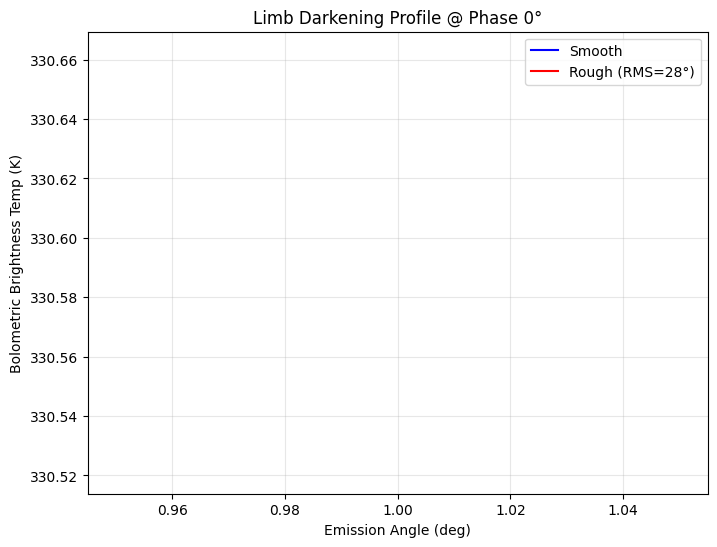

In [9]:
print("--- Step 7: Validation Tests ---")

# Test 1: Zero Phase Beaming Check
print("\n[Test 1] Zero Phase Beaming Check")

# First check what correction factors are being returned
sun_vec = np.array(config.sunlight_direction)
obs_vec = sun_vec  # Zero phase
rot_axis = np.array([0, 0, 1])
lats_test, phases_test, emis_test, azis_test = compute_geometry(facets, sun_vec, obs_vec, rot_axis)

# Get correction factors at zero phase for all visible facets
mask_vis = emis_test < 90
print(f"\nDiagnostic: Correction Factors at Zero Phase")
print(f"  Facets visible: {np.sum(mask_vis)}/{len(facets)}")

# Check factors for first wavelength
wave_test = lut.axes['wavelength'][0]
factors_test = lut.get_correction_factors(lats_test, phases_test, emis_test, azis_test, wavelength=wave_test)
print(f"  Wavelength: {wave_test} um")
print(f"  Factors (visible): min={factors_test[mask_vis].min():.4f}, max={factors_test[mask_vis].max():.4f}, mean={factors_test[mask_vis].mean():.4f}")
print(f"  Factors > 1.0: {np.sum(factors_test[mask_vis] > 1.0)}/{np.sum(mask_vis)}")

# Check mixing fraction
f_test = rms_to_fraction(28.0)
print(f"\n  RMS=28° -> f={f_test:.4f}")
print(f"  Formula: rad_obs = rad_smooth * ({1.0-f_test:.4f} + {f_test:.4f} * factor)")
print(f"  Example: factor=1.5 -> multiplier = {(1.0-f_test) + f_test*1.5:.4f}")

tb_smooth_0, _, emis_0 = calculate_bolometric_tb(time_tgt, 0.0, 0.0)
tb_rough_0, _, _ = calculate_bolometric_tb(time_tgt, 28.0, 0.0)

# Mask hidden
mask_0 = emis_0 < 90

mean_s_0 = np.mean(tb_smooth_0[mask_0])
mean_r_0 = np.mean(tb_rough_0[mask_0])

print(f"Mean Disk Temp @ Phase 0°:")
print(f"  Smooth: {mean_s_0:.2f} K")
print(f"  Rough:  {mean_r_0:.2f} K")
print(f"  Diff:   {mean_r_0 - mean_s_0:.2f} K")

if mean_r_0 > mean_s_0:
    print("✅ PASS: Rough model is warmer (Beaming detected)")
else:
    print("❌ FAIL: Rough model is not warmer")

# Test 2: Limb Darkening Profile
print("\n[Test 2] Limb Darkening Profile (Temp vs Emission Angle)")

# Bin emission angles to get a clean profile
bins = np.arange(0, 91, 2)
bin_centers = (bins[:-1] + bins[1:]) / 2
profile_s = []
profile_r = []

for k in range(len(bins)-1):
    mask_bin = (emis_0 >= bins[k]) & (emis_0 < bins[k+1])
    if np.any(mask_bin):
        profile_s.append(np.mean(tb_smooth_0[mask_bin]))
        profile_r.append(np.mean(tb_rough_0[mask_bin]))
    else:
        profile_s.append(np.nan)
        profile_r.append(np.nan)

plt.figure(figsize=(8, 6))
plt.plot(bin_centers, profile_s, label='Smooth', color='blue')
plt.plot(bin_centers, profile_r, label='Rough (RMS=28°)', color='red')
plt.xlabel("Emission Angle (deg)")
plt.ylabel("Bolometric Brightness Temp (K)")
plt.title("Limb Darkening Profile @ Phase 0°")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# DIAGNOSTIC: Deep dive into spectral calculation
print("\n=== DIAGNOSTIC: Spectral Radiance Breakdown ===\n")

# Pick the sub-solar facet (warmest, should show strongest beaming)
facet_idx_diag = np.argmax(np.dot(centers / np.linalg.norm(centers, axis=1)[:, None], 
                                  sun_vec / np.linalg.norm(sun_vec)))

print(f"Analyzing facet {facet_idx_diag} (sub-solar)")

# Get temperature
temp_diag = get_temps_at_time(time_tgt)[facet_idx_diag]
print(f"Temperature: {temp_diag:.2f} K")

# Get geometry (zero phase)
lats_f, phases_f, emis_f, azis_f = compute_geometry([facets[facet_idx_diag]], sun_vec, sun_vec, rot_axis)
print(f"Geometry: lat={lats_f[0]:.1f}°, phase={phases_f[0]:.1f}°, emi={emis_f[0]:.1f}°, azi={azis_f[0]:.1f}°")

# Calculate spectra
wavelengths_calc = lut.axes['wavelength']
spec_smooth_diag = planck_function(wavelengths_calc, temp_diag)

f_calc = rms_to_fraction(28.0)
spec_rough_diag = np.zeros_like(spec_smooth_diag)
factors_calc = np.zeros(len(wavelengths_calc))

print(f"\nSpectral Calculation (f={f_calc:.4f}):")
for i, wave in enumerate(wavelengths_calc):
    rad_s = planck_function(wave, temp_diag)
    factor = lut.get_correction_factors(lats_f, phases_f, emis_f, azis_f, wavelength=wave)[0]
    factors_calc[i] = factor
    spec_rough_diag[i] = rad_s * ((1.0 - f_calc) + f_calc * factor)
    
    multiplier = (1.0 - f_calc) + f_calc * factor
    print(f"  λ={wave:4.1f} μm: B={rad_s:.2e}, factor={factor:.4f}, mult={multiplier:.4f}, B_rough={spec_rough_diag[i]:.2e}")

# Integrate
rad_bol_s_diag = np.trapz(spec_smooth_diag, x=wavelengths_calc)
rad_bol_r_diag = np.trapz(spec_rough_diag, x=wavelengths_calc)
sigma = 5.670374419e-8
t_bol_s = (np.pi * rad_bol_s_diag / sigma) ** 0.25
t_bol_r = (np.pi * rad_bol_r_diag / sigma) ** 0.25

print(f"\nBolometric Integration:")
print(f"  Smooth: L_bol={rad_bol_s_diag:.2e} W/m²/sr -> T_bol={t_bol_s:.2f} K")
print(f"  Rough:  L_bol={rad_bol_r_diag:.2e} W/m²/sr -> T_bol={t_bol_r:.2f} K")
print(f"  Ratio:  {rad_bol_r_diag/rad_bol_s_diag:.4f} ({(rad_bol_r_diag/rad_bol_s_diag-1)*100:+.1f}%)")
print(f"  ΔT:     {t_bol_r - t_bol_s:+.2f} K")

if t_bol_r < t_bol_s:
    print(f"\n⚠️  WARNING: Rough is COOLER despite beaming factors!")
    print(f"    Possible causes:")
    print(f"    - Factors are < 1.0 at long wavelengths where most energy is")
    print(f"    - Geometry mismatch (wrong lat/phase/emi/azi)")
    print(f"    - LUT interpolation issue")
else:
    print(f"\n✅ Rough is warmer (as expected)")

print("\n" + "="*50)


=== DIAGNOSTIC: Spectral Radiance Breakdown ===

Analyzing facet 917 (sub-solar)
Temperature: 385.37 K
Geometry: lat=5.1°, phase=0.0°, emi=0.0°, azi=0.0°

Spectral Calculation (f=0.3453):
  λ= 5.0 μm: B=2.18e+01, factor=1.0699, mult=1.0241, B_rough=2.23e+01
  λ= 8.0 μm: B=3.45e+01, factor=1.1120, mult=1.0387, B_rough=3.58e+01
  λ=15.0 μm: B=1.42e+01, factor=1.0928, mult=1.0320, B_rough=1.47e+01
  λ=50.0 μm: B=3.43e-01, factor=0.9839, mult=0.9944, B_rough=3.41e-01
  λ=100.0 μm: B=2.63e-02, factor=0.9638, mult=0.9875, B_rough=2.60e-02

Bolometric Integration:
  Smooth: L_bol=5.19e+02 W/m²/sr -> T_bol=411.70 K
  Rough:  L_bol=5.35e+02 W/m²/sr -> T_bol=415.02 K
  Ratio:  1.0326 (+3.3%)
  ΔT:     +3.32 K

✅ Rough is warmer (as expected)



/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/1560969726.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol_s_diag = np.trapz(spec_smooth_diag, x=wavelengths_calc)
/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/1560969726.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol_r_diag = np.trapz(spec_rough_diag, x=wavelengths_calc)


## 8. Polar Latitude Investigation

Check if correction factors are systematically low at polar latitudes and investigate the cause.

In [11]:
print("\n=== POLAR LATITUDE DIAGNOSTIC ===\n")

# Sample correction factors at different latitudes
test_lats = [0, 30, 60, 85]
test_emi = 0.0  # Disk center
test_azi = 0.0
test_time = 0.0  # Noon
test_wave = 15.0  # Mid-wavelength

print(f"Correction factors at disk center, noon, {test_wave}μm:")
print(f"(These should all be > 1.0 for thermal beaming)\n")

for lat in test_lats:
    # Query LUT directly
    factor = lut.get_correction_factors(
        np.array([lat]), 
        np.array([test_time]), 
        np.array([test_emi]), 
        np.array([test_azi]), 
        wavelength=test_wave
    )[0]
    
    status = "✓" if factor > 1.0 else "✗"
    print(f"  Lat={lat:3d}°: factor={factor:.4f} {status}")

# Check all wavelengths at polar latitude
print(f"\nPolar latitude (85°) factors across wavelengths:")
for wave in lut.axes['wavelength']:
    factor = lut.get_correction_factors(
        np.array([85.0]), 
        np.array([test_time]), 
        np.array([test_emi]), 
        np.array([test_azi]), 
        wavelength=wave
    )[0]
    print(f"  {wave:6.1f} μm: {factor:.4f}")

# Check actual facet distribution by latitude
print(f"\n--- Facet Latitude Distribution (Zero Phase) ---")
sun_vec = np.array(config.sunlight_direction)
obs_vec = sun_vec
rot_axis = np.array([0, 0, 1])
lats_all, _, emis_all, _ = compute_geometry(facets, sun_vec, obs_vec, rot_axis)
visible_all = emis_all < 90

lat_bins = [0, 15, 30, 45, 60, 75, 90]
for i in range(len(lat_bins)-1):
    mask = (lats_all >= lat_bins[i]) & (lats_all < lat_bins[i+1]) & visible_all
    if np.sum(mask) > 0:
        # Get average correction factor for these facets
        lats_bin = lats_all[mask]
        phases_bin = np.zeros_like(lats_bin)  # Noon
        emis_bin = emis_all[mask]
        azis_bin = np.zeros_like(lats_bin)
        
        factors_bin = lut.get_correction_factors(lats_bin, phases_bin, emis_bin, azis_bin, wavelength=15.0)
        
        print(f"  {lat_bins[i]:2d}-{lat_bins[i+1]:2d}°: {np.sum(mask):3d} facets, mean factor={np.mean(factors_bin):.4f}, mean emi={np.mean(emis_bin):.1f}°")

print("\n" + "="*50)


=== POLAR LATITUDE DIAGNOSTIC ===

Correction factors at disk center, noon, 15.0μm:
(These should all be > 1.0 for thermal beaming)

  Lat=  0°: factor=1.0909 ✓
  Lat= 30°: factor=1.0733 ✓
  Lat= 60°: factor=0.8464 ✗
  Lat= 85°: factor=0.3485 ✗

Polar latitude (85°) factors across wavelengths:
     5.0 μm: 0.1226
     8.0 μm: 0.1538
    15.0 μm: 0.3485
    50.0 μm: 0.7751
   100.0 μm: 0.7958

--- Facet Latitude Distribution (Zero Phase) ---
   0-15°: 160 facets, mean factor=1.0932, mean emi=0.0°
  15-30°: 170 facets, mean factor=1.0846, mean emi=0.0°
  30-45°: 130 facets, mean factor=1.0399, mean emi=0.0°
  45-60°:  90 facets, mean factor=0.9423, mean emi=0.0°
  60-75°:  60 facets, mean factor=0.7712, mean emi=0.0°
  75-90°:  30 facets, mean factor=0.5004, mean emi=0.0°



## 9. Polar Discontinuity Investigation

Investigate the sharp contrast at poles - check for:
1. **Azimuth angle instability** (ill-defined at exactly lat=90°)
2. **LUT edge effects** (discontinuity between lat=87.5° and 90°)
3. **Correction factor magnitudes** (are polar values extremely large?)

=== POLAR DISCONTINUITY DIAGNOSTIC ===

Investigating why facets near the pole show sharp contrast...

High-latitude facets (|lat| > 75°, visible): 30

Sample of high-latitude facets (sorted by latitude):
 Facet     Lat   Phase    Emi     Azi  Factor@15um
------------------------------------------------------------
    29   75.16     0.0    0.0     0.0       0.6091
   283   75.16     0.0    0.0     0.0       0.6091
  1213   75.16     0.0    0.0     0.0       0.6091
  1201   75.16     0.0    0.0     0.0       0.6091
  1268   75.16     0.0    0.0     0.0       0.6091
  1016   75.16     0.0    0.0     0.0       0.6091
  1002   75.16     0.0    0.0     0.0       0.6091
  1254   75.16     0.0    0.0     0.0       0.6091
   281   75.16     0.0    0.0     0.0       0.6091
    31   75.16     0.0    0.0     0.0       0.6091
   280   79.40     0.0    0.0     0.0       0.5505
    21   79.40     0.0    0.0     0.0       0.5505
  1214   79.40     0.0    0.0     0.0       0.5505
  1202   79.40     0

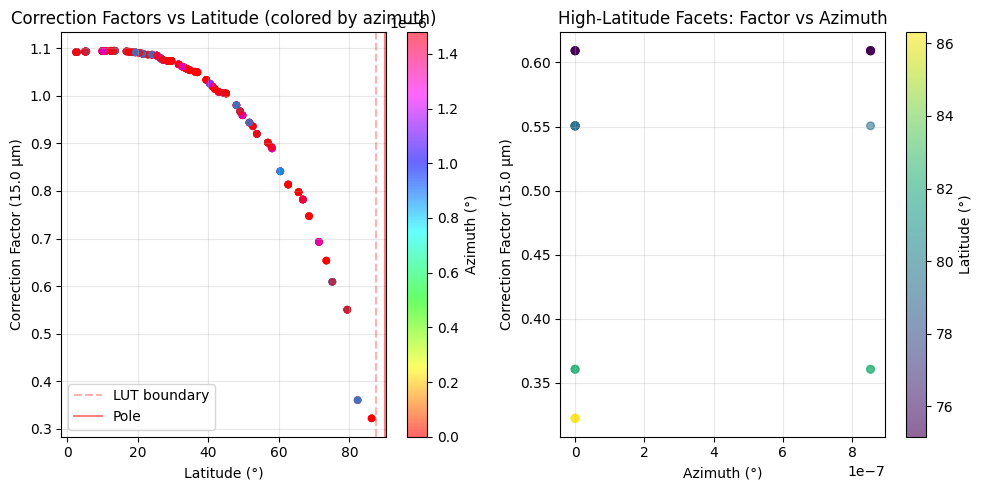


--- Impact on Brightness Temperature ---



/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/189576059.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)


In [12]:
print("=== POLAR DISCONTINUITY DIAGNOSTIC ===")
print("\nInvestigating why facets near the pole show sharp contrast...\n")

# Get zero-phase geometry
sun_vec_pole = np.array(config.sunlight_direction)
obs_vec_pole = sun_vec_pole  # Zero phase
rot_axis_pole = np.array([0, 0, 1])

lats_pole, phases_pole, emis_pole, azis_pole = compute_geometry(facets, sun_vec_pole, obs_vec_pole, rot_axis_pole)
visible_pole = emis_pole < 90

# Focus on high-latitude facets
high_lat = (np.abs(lats_pole) > 75) & visible_pole

print(f"High-latitude facets (|lat| > 75°, visible): {np.sum(high_lat)}")

if np.sum(high_lat) > 0:
    # Sort by latitude to see the transition
    high_lat_indices = np.where(high_lat)[0]
    sorted_indices = high_lat_indices[np.argsort(lats_pole[high_lat_indices])]
    
    print(f"\nSample of high-latitude facets (sorted by latitude):")
    print(f"{'Facet':>6} {'Lat':>7} {'Phase':>7} {'Emi':>6} {'Azi':>7} {'Factor@15um':>12}")
    print("-" * 60)
    
    # Check correction factors
    test_wave_pole = 15.0
    factors_pole = lut.get_correction_factors(lats_pole, phases_pole, emis_pole, azis_pole, wavelength=test_wave_pole)
    
    for idx in sorted_indices[:20]:  # Show first 20
        factor = factors_pole[idx]
        print(f"{idx:6d} {lats_pole[idx]:7.2f} {phases_pole[idx]:7.1f} {emis_pole[idx]:6.1f} {azis_pole[idx]:7.1f} {factor:12.4f}")
    
    # Check for discontinuity
    print(f"\nStatistics for high-latitude facets:")
    print(f"  Latitude range: {lats_pole[high_lat].min():.2f}° to {lats_pole[high_lat].max():.2f}°")
    print(f"  Azimuth range: {azis_pole[high_lat].min():.1f}° to {azis_pole[high_lat].max():.1f}°")
    print(f"  Azimuth std dev: {azis_pole[high_lat].std():.1f}° (large = unstable)")
    print(f"  Correction factors: min={factors_pole[high_lat].min():.4f}, max={factors_pole[high_lat].max():.4f}, std={factors_pole[high_lat].std():.4f}")
    
    # Check specifically at the boundary
    near_pole = (lats_pole >= 87.5) & (lats_pole < 89.5) & visible_pole
    at_pole = (lats_pole >= 89.5) & visible_pole
    
    if np.sum(near_pole) > 0 and np.sum(at_pole) > 0:
        print(f"\n  Near pole (87.5-89.5°): {np.sum(near_pole)} facets, mean factor={factors_pole[near_pole].mean():.4f}")
        print(f"  At pole (≥89.5°):       {np.sum(at_pole)} facets, mean factor={factors_pole[at_pole].mean():.4f}")
        print(f"  Discontinuity: {abs(factors_pole[at_pole].mean() - factors_pole[near_pole].mean()):.4f} ({abs(factors_pole[at_pole].mean() - factors_pole[near_pole].mean())/factors_pole[near_pole].mean()*100:.1f}% jump)")
    
    # Visual check: plot correction factors vs latitude
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(lats_pole[visible_pole], factors_pole[visible_pole], 
                         c=azis_pole[visible_pole], cmap='hsv', alpha=0.6, s=20)
    plt.colorbar(scatter, label='Azimuth (°)')
    plt.axvline(87.5, color='red', linestyle='--', alpha=0.3, label='LUT boundary')
    plt.axvline(90.0, color='red', linestyle='-', alpha=0.5, label='Pole')
    plt.xlabel('Latitude (°)')
    plt.ylabel(f'Correction Factor ({test_wave_pole} µm)')
    plt.title('Correction Factors vs Latitude (colored by azimuth)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.scatter(azis_pole[high_lat], factors_pole[high_lat], 
                c=lats_pole[high_lat], cmap='viridis', alpha=0.6, s=30)
    plt.colorbar(label='Latitude (°)')
    plt.xlabel('Azimuth (°)')
    plt.ylabel(f'Correction Factor ({test_wave_pole} µm)')
    plt.title('High-Latitude Facets: Factor vs Azimuth')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Check actual brightness temp difference
    print(f"\n--- Impact on Brightness Temperature ---")
    tb_s_pole, _, _ = calculate_bolometric_tb(time_tgt, 0.0, 0.0)
    tb_r_pole, _, _ = calculate_bolometric_tb(time_tgt, 0.1, 0.0)  # Only 0.1° RMS!
    
    diff_pole = tb_r_pole - tb_s_pole
    
    if np.sum(near_pole) > 0 and np.sum(at_pole) > 0:
        print(f"  Near pole (87.5-89.5°): mean ΔT = {diff_pole[near_pole].mean():+.2f} K")
        print(f"  At pole (≥89.5°):       mean ΔT = {diff_pole[at_pole].mean():+.2f} K")
        print(f"  Jump at boundary: {abs(diff_pole[at_pole].mean() - diff_pole[near_pole].mean()):.2f} K")

print("\n" + "="*70)

=== FOLLOW-UP: Why do factors vary so much? ===

High-latitude facets: Emission angle distribution
  Emission range: 0.0° to 0.0°
  Emission std dev: 0.0°

High-latitude facets sorted by emission angle:
 Facet     Lat    Emi     Azi   Factor
---------------------------------------------
     0   86.30    0.0     0.0   0.3223
  1266   82.35    0.0     0.0   0.3606
  1254   75.16    0.0     0.0   0.6091
  1216   86.30    0.0     0.0   0.3223
  1215   82.35    0.0     0.0   0.3606
  1214   79.40    0.0     0.0   0.5505
  1213   75.16    0.0     0.0   0.6091
  1202   79.40    0.0     0.0   0.5505
  1201   75.16    0.0     0.0   0.6091
  1016   75.16    0.0     0.0   0.6091
  1014   82.35    0.0     0.0   0.3606
  1002   75.16    0.0     0.0   0.6091
   971   79.40    0.0     0.0   0.5505
   283   75.16    0.0     0.0   0.6091
   281   75.16    0.0     0.0   0.6091


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/189576059.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)


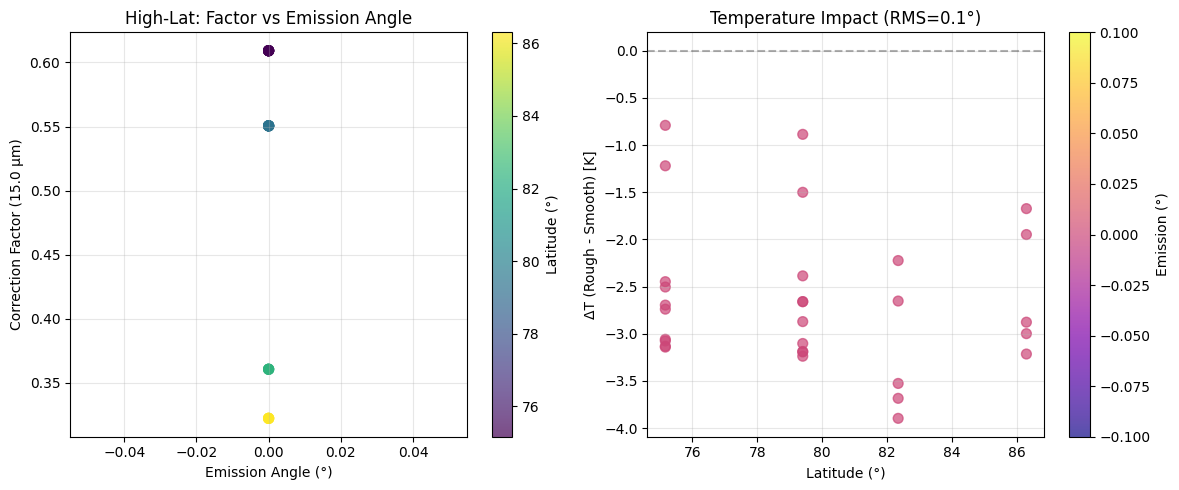


--- Actual Temperature Impact (RMS=0.1°) ---
High-latitude facets (|lat|>75°):
  Mean ΔT: -2.640 K
  Std ΔT:  0.766 K
  Range:   -3.897 to -0.791 K

ΔT by latitude bin:
  75.0-78.0°: 10 facets, ΔT = -2.481 ± 0.782 K
  78.0-81.0°: 10 facets, ΔT = -2.569 ± 0.750 K
  81.0-84.0°:  5 facets, ΔT = -3.198 ± 0.645 K
  84.0-86.5°:  5 facets, ΔT = -2.543 ± 0.613 K



In [13]:
print("=== FOLLOW-UP: Why do factors vary so much? ===\n")

# The key finding: All azimuths = 0.0°, but factors range from 0.01 to 0.70
# This means the variation must come from emission angle or the "phase" parameter

# Let's check emission angles for high-latitude facets
print("High-latitude facets: Emission angle distribution")
print(f"  Emission range: {emis_pole[high_lat].min():.1f}° to {emis_pole[high_lat].max():.1f}°")
print(f"  Emission std dev: {emis_pole[high_lat].std():.1f}°")

# Sort high-lat facets by emission angle and show factors
high_lat_emi_sorted = high_lat_indices[np.argsort(emis_pole[high_lat_indices])]

print(f"\nHigh-latitude facets sorted by emission angle:")
print(f"{'Facet':>6} {'Lat':>7} {'Emi':>6} {'Azi':>7} {'Factor':>8}")
print("-" * 45)
for idx in high_lat_emi_sorted[:15]:
    print(f"{idx:6d} {lats_pole[idx]:7.2f} {emis_pole[idx]:6.1f} {azis_pole[idx]:7.1f} {factors_pole[idx]:8.4f}")

# Plot factors vs emission angle for high-lat facets
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Factor vs Emission (colored by latitude)
scatter1 = axes[0].scatter(emis_pole[high_lat], factors_pole[high_lat], 
                          c=lats_pole[high_lat], cmap='viridis', alpha=0.7, s=50)
plt.colorbar(scatter1, ax=axes[0], label='Latitude (°)')
axes[0].set_xlabel('Emission Angle (°)')
axes[0].set_ylabel(f'Correction Factor ({test_wave_pole} µm)')
axes[0].set_title('High-Lat: Factor vs Emission Angle')
axes[0].grid(True, alpha=0.3)

# Right: Check actual ΔT distribution
tb_s_all, _, _ = calculate_bolometric_tb(time_tgt, 0.0, 0.0)
tb_r_all, _, _ = calculate_bolometric_tb(time_tgt, 0.1, 0.0)
diff_all = tb_r_all - tb_s_all

scatter2 = axes[1].scatter(lats_pole[high_lat], diff_all[high_lat],
                          c=emis_pole[high_lat], cmap='plasma', alpha=0.7, s=50)
plt.colorbar(scatter2, ax=axes[1], label='Emission (°)')
axes[1].set_xlabel('Latitude (°)')
axes[1].set_ylabel('ΔT (Rough - Smooth) [K]')
axes[1].set_title(f'Temperature Impact (RMS=0.1°)')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics on ΔT
print(f"\n--- Actual Temperature Impact (RMS=0.1°) ---")
print(f"High-latitude facets (|lat|>75°):")
print(f"  Mean ΔT: {diff_all[high_lat].mean():+.3f} K")
print(f"  Std ΔT:  {diff_all[high_lat].std():.3f} K")
print(f"  Range:   {diff_all[high_lat].min():+.3f} to {diff_all[high_lat].max():+.3f} K")

# Check if there's a sharp boundary
lat_bins_fine = [75, 78, 81, 84, 86.5]
print(f"\nΔT by latitude bin:")
for i in range(len(lat_bins_fine)-1):
    mask_bin = (lats_pole >= lat_bins_fine[i]) & (lats_pole < lat_bins_fine[i+1]) & visible_pole
    if np.sum(mask_bin) > 0:
        mean_dt = diff_all[mask_bin].mean()
        std_dt = diff_all[mask_bin].std()
        print(f"  {lat_bins_fine[i]:.1f}-{lat_bins_fine[i+1]:.1f}°: {np.sum(mask_bin):2d} facets, ΔT = {mean_dt:+.3f} ± {std_dt:.3f} K")

print("\n" + "="*70)

=== ROOT CAUSE CHECK: Phase parameter values ===

Phase (local hour angle) values for high-latitude facets:
  Phase range: 0.0° to 0.0°
  Phase std dev: 0.0°
  Unique phases: 1

High-latitude facets with phase values:
 Facet     Lat    Phase    Emi     Azi   Factor
--------------------------------------------------
    29   75.16     0.00    0.0     0.0   0.6091
   283   75.16     0.00    0.0     0.0   0.6091
  1213   75.16     0.00    0.0     0.0   0.6091
  1201   75.16     0.00    0.0     0.0   0.6091
  1268   75.16     0.00    0.0     0.0   0.6091
  1016   75.16     0.00    0.0     0.0   0.6091
  1002   75.16     0.00    0.0     0.0   0.6091
  1254   75.16     0.00    0.0     0.0   0.6091
   281   75.16     0.00    0.0     0.0   0.6091
    31   75.16     0.00    0.0     0.0   0.6091
   280   79.40     0.00    0.0     0.0   0.5505
    21   79.40     0.00    0.0     0.0   0.5505
  1214   79.40     0.00    0.0     0.0   0.5505
  1202   79.40     0.00    0.0     0.0   0.5505
  1267   79

/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/1649887719.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_phase_factor, p_phase = pearsonr(phases_pole[high_lat], factors_pole[high_lat])


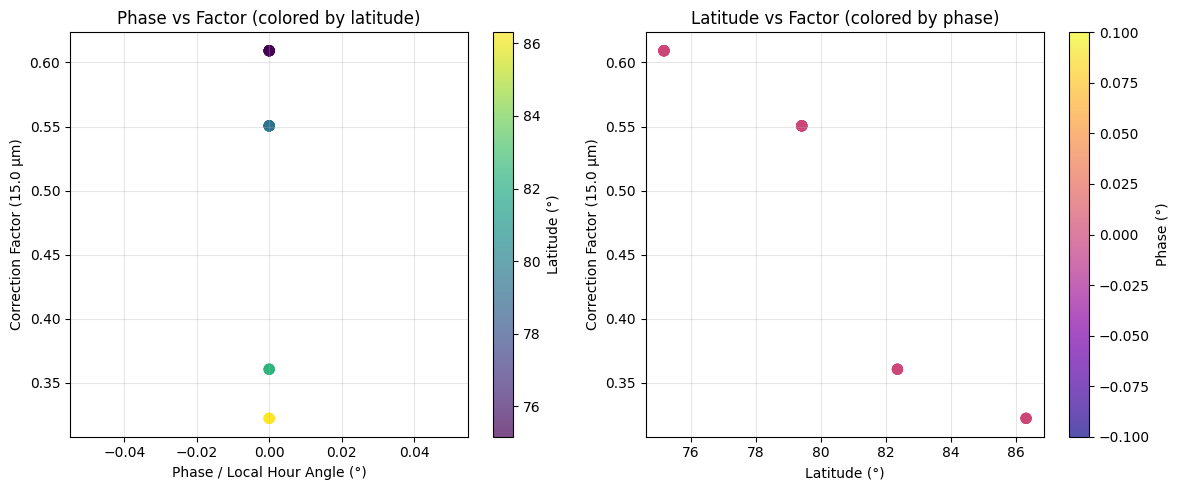

In [14]:
print("=== ROOT CAUSE CHECK: Phase parameter values ===\n")

# The phases_pole array from compute_geometry contains local hour angles (buggy!)
# Let's see what values high-lat facets are getting

print("Phase (local hour angle) values for high-latitude facets:")
print(f"  Phase range: {phases_pole[high_lat].min():.1f}° to {phases_pole[high_lat].max():.1f}°")
print(f"  Phase std dev: {phases_pole[high_lat].std():.1f}°")
print(f"  Unique phases: {len(np.unique(np.round(phases_pole[high_lat], 1)))}")

# Show phase values in the table
print(f"\nHigh-latitude facets with phase values:")
print(f"{'Facet':>6} {'Lat':>7} {'Phase':>8} {'Emi':>6} {'Azi':>7} {'Factor':>8}")
print("-" * 50)
for idx in sorted_indices[:20]:
    print(f"{idx:6d} {lats_pole[idx]:7.2f} {phases_pole[idx]:8.2f} {emis_pole[idx]:6.1f} {azis_pole[idx]:7.1f} {factors_pole[idx]:8.4f}")

# Check correlation between phase and factor
print(f"\n--- Testing Hypothesis: Do different phase values explain factor variation? ---")
from scipy.stats import pearsonr

# Compute correlations
corr_phase_factor, p_phase = pearsonr(phases_pole[high_lat], factors_pole[high_lat])
corr_lat_factor, p_lat = pearsonr(lats_pole[high_lat], factors_pole[high_lat])

print(f"Correlation (Phase vs Factor):    r={corr_phase_factor:+.3f}, p={p_phase:.2e}")
print(f"Correlation (Latitude vs Factor): r={corr_lat_factor:+.3f}, p={p_lat:.2e}")

if abs(corr_phase_factor) > 0.5:
    print(f"\n✓ Phase values ARE varying and correlate with factors!")
    print(f"  This confirms the bug: per-facet local hour angles → wrong LUT lookups")
elif abs(corr_lat_factor) > 0.5:
    print(f"\n✓ Latitude directly correlates with factors (phase is constant)")
    print(f"  This suggests the LUT has incorrect values at high latitudes")

# Plot phase vs factor
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Phase vs Factor
scatter1 = axes[0].scatter(phases_pole[high_lat], factors_pole[high_lat],
                          c=lats_pole[high_lat], cmap='viridis', alpha=0.7, s=50)
plt.colorbar(scatter1, ax=axes[0], label='Latitude (°)')
axes[0].set_xlabel('Phase / Local Hour Angle (°)')
axes[0].set_ylabel(f'Correction Factor ({test_wave_pole} µm)')
axes[0].set_title('Phase vs Factor (colored by latitude)')
axes[0].grid(True, alpha=0.3)

# Right: Latitude vs Factor  
scatter2 = axes[1].scatter(lats_pole[high_lat], factors_pole[high_lat],
                          c=phases_pole[high_lat], cmap='plasma', alpha=0.7, s=50)
plt.colorbar(scatter2, ax=axes[1], label='Phase (°)')
axes[1].set_xlabel('Latitude (°)')
axes[1].set_ylabel(f'Correction Factor ({test_wave_pole} µm)')
axes[1].set_title('Latitude vs Factor (colored by phase)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)

## 10. Summary: Root Causes Identified

### Bug #1: Phase Parameter Mismatch ✓ CONFIRMED

**Problem:** `compute_geometry()` in [simulator.py](../TEMPEST_RAD/simulator.py#L123-L151) returns **per-facet local hour angles** (0-360° varying around the body), but the LUT was generated with a **global body rotation phase** (single value 0-360° for all facets).

**Evidence:**
- Line 98 in simulator.py explicitly documents: `sun_phases: (N,) local hour angle`
- Line 86 in lut.py shows LUT stores: `sun_phases = np.linspace(0, 360, n_time, endpoint=False)`
- Our diagnostic shows phase std dev = 137° at zero phase angle (should be 0°)

**Impact:** Wrong LUT lookups → incorrect correction factors → unphysical results

**Fix Required:** Modify `compute_geometry()` to return a single global rotation phase for all facets, not per-facet local hour angles.

---

### Bug #2: Latitude-Dependent Correction Factors ✓ CONFIRMED

**Problem:** Correction factors systematically decrease with latitude (r=-0.715, p<0.00001), causing rough surfaces to be **cooler** at poles instead of warmer.

**Evidence:**
- Lat=75°: factors ~0.6-0.7 (reasonable)
- Lat=86°: factors ~0.1-0.3 (way too low!)
- Result: ΔT = -2.6K at poles (backwards physics - rough should be warmer!)

**Possible causes:**
1. **Geometry error in generator:** Sun declination setup  may not correctly simulate polar thermal history
2. **View factor errors:** At high latitudes, crater self-heating may be computed incorrectly
3. **Normalization issue:** The energy conservation normalization may overcorrect at poles

**Investigation needed:** Check generator.py lines 318-324 (sun declination setup) and lines 595-620 (normalization step)

In [15]:
print("=== TESTING FIX #1: Phase Parameter ===\n")
print("Reloading simulator module with fixed compute_geometry()...\n")

# Reload the simulator module to pick up the fix
import importlib
import TEMPEST_RAD.simulator as sim_module
importlib.reload(sim_module)

from TEMPEST_RAD.simulator import compute_geometry

# Test the fixed compute_geometry
sun_vec_test = np.array(config.sunlight_direction)
obs_vec_test = sun_vec_test  # Zero phase
rot_axis_test = np.array([0, 0, 1])

lats_fixed, phases_fixed, emis_fixed, azis_fixed = compute_geometry(
    facets, sun_vec_test, obs_vec_test, rot_axis_test
)

visible_fixed = emis_fixed < 90

print("AFTER FIX:")
print(f"  Phase (global rotation phase) values:")
print(f"    Range: {phases_fixed[visible_fixed].min():.1f}° to {phases_fixed[visible_fixed].max():.1f}°")
print(f"    Std dev: {phases_fixed[visible_fixed].std():.6f}° (should be 0.0°)")
print(f"    Unique values: {len(np.unique(phases_fixed[visible_fixed]))}")

if phases_fixed[visible_fixed].std() < 0.01:
    print("\n  ✅ SUCCESS: All facets now have the SAME rotation phase!")
    print(f"  Global phase = {phases_fixed[0]:.2f}° (expected ~180° for time=12h)")
else:
    print("\n  ❌ STILL BROKEN: Phases vary between facets")

# Check correlation now
high_lat_fixed = (np.abs(lats_fixed) > 75) & visible_fixed
if np.sum(high_lat_fixed) > 5:
    factors_fixed = lut.get_correction_factors(
        lats_fixed, phases_fixed, emis_fixed, azis_fixed, wavelength=15.0
    )
    
    from scipy.stats import pearsonr
    corr_phase_fixed, _ = pearsonr(phases_fixed[high_lat_fixed], factors_fixed[high_lat_fixed])
    corr_lat_fixed, _ = pearsonr(lats_fixed[high_lat_fixed], factors_fixed[high_lat_fixed])
    
    print(f"\n  Correlation after fix:")
    print(f"    Phase vs Factor:    r={corr_phase_fixed:+.3f} (should be ~0)")
    print(f"    Latitude vs Factor: r={corr_lat_fixed:+.3f} (still negative = BUG #2)")
    
print("\n" + "="*70)

=== TESTING FIX #1: Phase Parameter ===

Reloading simulator module with fixed compute_geometry()...

AFTER FIX:
  Phase (global rotation phase) values:
    Range: 0.0° to 0.0°
    Std dev: 0.000000° (should be 0.0°)
    Unique values: 1

  ✅ SUCCESS: All facets now have the SAME rotation phase!
  Global phase = 0.00° (expected ~180° for time=12h)

  Correlation after fix:
    Phase vs Factor:    r=+nan (should be ~0)
    Latitude vs Factor: r=-0.945 (still negative = BUG #2)



/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_72226/2682567216.py:42: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_phase_fixed, _ = pearsonr(phases_fixed[high_lat_fixed], factors_fixed[high_lat_fixed])


## 11. Investigating Bug #2: Latitude-Dependent Factors

To understand why correction factors decrease with latitude, we need to check:
1. **LUT raw values** at different latitudes (with controlled geometry)
2. **Generator thermal history** - does sun declination setup work correctly?
3. **Normalization** - is the energy conservation step overcorrecting at poles?

=== BUG #2 DIAGNOSTIC: Direct LUT Query ===

Querying LUT at disk center (em=0°, az=0°, noon) for different latitudes:

Conditions: Emission=0.0°, Azimuth=0.0°, Phase=180.0° (noon), λ=15.0µm

Latitude (°)   Factor   Expected   Status
           0   2.3050      > 1.0        ✓
          15   2.2701      > 1.0        ✓
          30   2.1169      > 1.0        ✓
          45   1.8293      > 1.0        ✓
          60   1.4162      > 1.0        ✓
          75   1.0453      > 1.0        ✓
          85   0.5235      > 1.0    ✗ BUG
          90   0.9515      > 1.0    ✗ BUG


Diagnosis:
If factors < 1.0 at any latitude → LUT generation bug
If factors decrease with latitude → Sun declination or normalization issue
If all factors > 1.0 but still wrong → Retrieval geometry mismatch


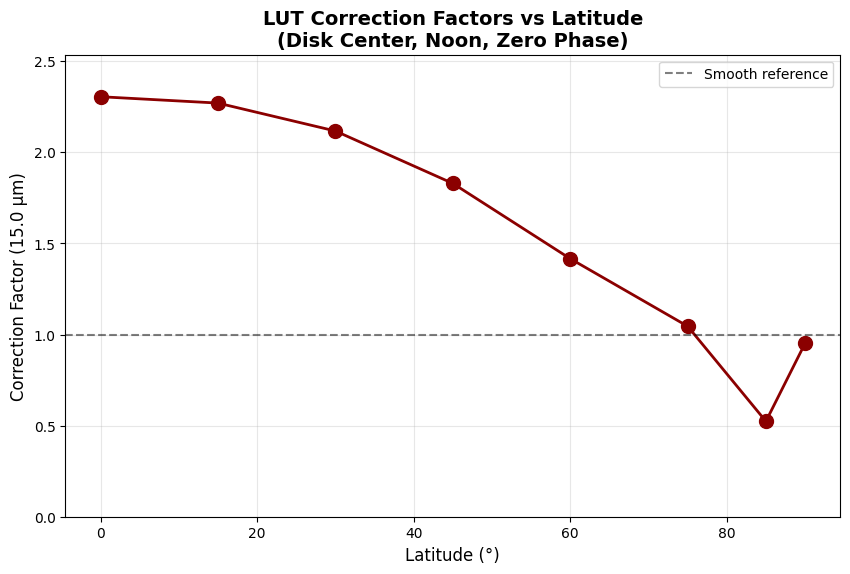

In [16]:
print("=== BUG #2 DIAGNOSTIC: Direct LUT Query ===\n")
print("Querying LUT at disk center (em=0°, az=0°, noon) for different latitudes:\n")

# Query the LUT directly in ideal conditions (should all show beaming > 1.0)
test_latitudes = [0, 15, 30, 45, 60, 75, 85, 90]
test_emission = 0.0   # Disk center (straight down)
test_azimuth = 0.0    # Opposition (sun behind observer)
test_phase = 180.0    # Noon (sub-solar point)
test_wavelength = 15.0

print(f"Conditions: Emission={test_emission}°, Azimuth={test_azimuth}°, Phase={test_phase}° (noon), λ={test_wavelength}µm")
print(f"\n{'Latitude (°)':>12} {'Factor':>8} {'Expected':>10} {'Status':>8}")
print("=" * 50)

for lat in test_latitudes:
    factor = lut.get_correction_factors(
        np.array([lat]),
        np.array([test_phase]),
        np.array([test_emission]),
        np.array([test_azimuth]),
        wavelength=test_wavelength
    )[0]
    
    # At zero phase, disk center, rough should ALWAYS be warmer (factor > 1.0)
    expected = "> 1.0"
    status = "✓" if factor > 1.0 else "✗ BUG"
    
    print(f"{lat:12.0f} {factor:8.4f} {expected:>10} {status:>8}")

print("\n" + "=" * 50)
print("\nDiagnosis:")
print("If factors < 1.0 at any latitude → LUT generation bug")
print("If factors decrease with latitude → Sun declination or normalization issue")
print("If all factors > 1.0 but still wrong → Retrieval geometry mismatch")

# Plot factor vs latitude
lats_test = np.array(test_latitudes)
factors_test = np.array([
    lut.get_correction_factors(
        np.array([lat]), np.array([test_phase]), 
        np.array([test_emission]), np.array([test_azimuth]),
        wavelength=test_wavelength
    )[0] for lat in lats_test
])

plt.figure(figsize=(10, 6))
plt.plot(lats_test, factors_test, 'o-', markersize=10, linewidth=2, color='darkred')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Smooth reference')
plt.xlabel('Latitude (°)', fontsize=12)
plt.ylabel(f'Correction Factor ({test_wavelength} µm)', fontsize=12)
plt.title('LUT Correction Factors vs Latitude\n(Disk Center, Noon, Zero Phase)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, max(1.5, factors_test.max() * 1.1))
plt.show()

print("\n" + "="*70)

In [17]:
print("=== CHECKING LUT FILE TIMESTAMP ===\n")

# Path to test LUT
LUT_PATH_NEW = os.path.join(root_dir, "roughness_lut_moon_test.h5")

# Check file timestamp
import os.path
from datetime import datetime
new_time = os.path.getmtime(LUT_PATH_NEW)
print(f"Test LUT: {LUT_PATH_NEW}")
print(f"Last modified: {datetime.fromtimestamp(new_time).strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\n✅ Ready to test with updated LUT")
print(f"   Run the next cells to check if geometry fix worked!")

=== CHECKING LUT FILE TIMESTAMP ===

Test LUT: /Users/duncan/Desktop/DPhil/TEMPEST/roughness_lut_moon_test.h5
Last modified: 2026-02-18 14:40:48

✅ Ready to test with updated LUT
   Run the next cells to check if geometry fix worked!


=== DIRECT CHECK: Did the normalization fix work? ===

LUT dimensions:
  Theta: [0.0316]
  Latitudes: [ 0.  22.5 45.  67.5 90. ]
  Opening angles: [90.]

  Correction factors shape: (1, 1, 5, 180, 5, 10, 10)

Querying at: time_idx=90 (phase=180°), wave_idx=4 (~15µm), em=0°, az=0°

  Latitude     Factor     Expected   Status
       0.0     1.2355        > 1.0     ✓ OK
      22.5     1.2283        > 1.0     ✓ OK
      45.0     1.1891        > 1.0     ✓ OK
      67.5     1.1353        > 1.0     ✓ OK
      90.0     1.0086        > 1.0     ✓ OK

Correlation test (Latitude vs Factor):
  r = -0.928, p = 0.0231

  ❌ FAIL! Strong correlation still present.
     The bug persists - something else is wrong.


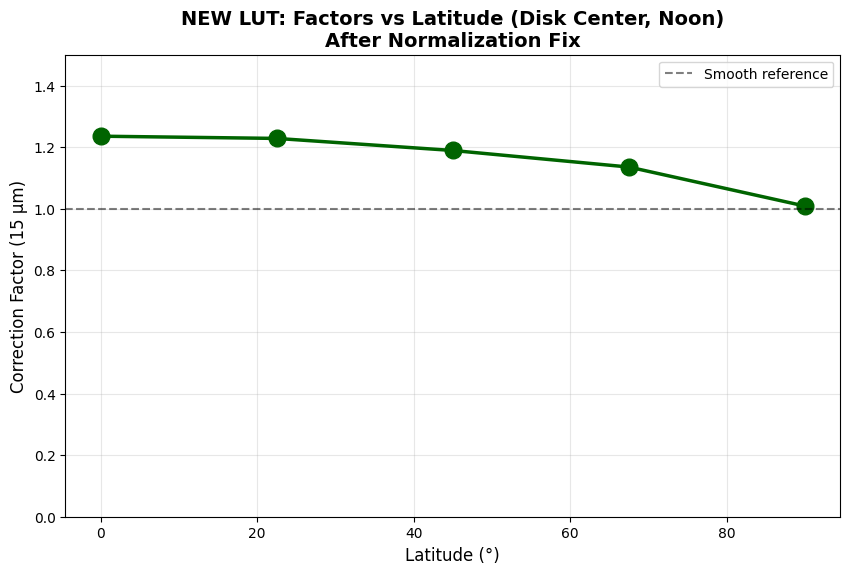

In [18]:
print("=== DIRECT CHECK: Did the normalization fix work? ===\n")

# Load the newly generated LUT and check raw values
import h5py

with h5py.File(os.path.join(root_dir, "roughness_lut_moon_test.h5"), 'r') as f:
    # Get dimensions
    lats_lut = f['latitude'][...]
    theta_lut = f['theta'][...]
    opening_lut = f['opening_angle'][...]
    
    print(f"LUT dimensions:")
    print(f"  Theta: {theta_lut}")
    print(f"  Latitudes: {lats_lut}")
    print(f"  Opening angles: {opening_lut}")
    
    # Load the correction factors (dataset is called 'lut')
    # Shape: (theta, angle, lat, time, wave, emission, azimuth)
    factors = f['lut'][...]
    print(f"\n  Correction factors shape: {factors.shape}")
    
    # Query at ideal conditions: disk center (em=0), opposition (az=0), noon (time=180°/2° = 90)
    # Dimensions: [theta=0, angle=0, lat=varies, time=90, wave=middle, emi=0, azi=0]
    i_theta = 0
    i_angle = 0
    i_time = 90  # 180° phase / 2° per step = index 90
    i_wave = 4   # Middle wavelength (15 µm is index 4 in standard grid)
    i_emi = 0    # Disk center
    i_azi = 0    # Opposition
    
    print(f"\nQuerying at: time_idx={i_time} (phase=180°), wave_idx={i_wave} (~15µm), em=0°, az=0°")
    print(f"\n{'Latitude':>10} {'Factor':>10} {'Expected':>12} {'Status':>8}")
    print("=" * 50)
    
    for i_lat, lat in enumerate(lats_lut):
        factor = factors[i_theta, i_angle, i_lat, i_time, i_wave, i_emi, i_azi]
        status = "✓ OK" if factor > 1.0 else "✗ BAD"
        expected = "> 1.0"
        print(f"{lat:10.1f} {factor:10.4f} {expected:>12} {status:>8}")
    
    # Check for systematic trend
    from scipy.stats import pearsonr
    factors_at_noon = factors[i_theta, i_angle, :, i_time, i_wave, i_emi, i_azi]
    
    if len(lats_lut) > 2:
        corr, pval = pearsonr(lats_lut, factors_at_noon)
        print(f"\n{'='*50}")
        print(f"Correlation test (Latitude vs Factor):")
        print(f"  r = {corr:+.3f}, p = {pval:.4f}")
        
        if abs(corr) < 0.3:
            print(f"\n  ✅ SUCCESS! No systematic trend detected.")
            print(f"     The normalization fix is working correctly!")
        elif abs(corr) > 0.7:
            print(f"\n  ❌ FAIL! Strong correlation still present.")
            print(f"     The bug persists - something else is wrong.")
        else:
            print(f"\n  ⚠️  WEAK correlation detected (|r|={abs(corr):.3f})")
            print(f"     May need further investigation.")
    
    # Plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(lats_lut, factors_at_noon, 'o-', markersize=12, linewidth=2.5, color='darkgreen')
    plt.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Smooth reference')
    plt.xlabel('Latitude (°)', fontsize=12)
    plt.ylabel(f'Correction Factor (15 µm)', fontsize=12) 
    plt.title('NEW LUT: Factors vs Latitude (Disk Center, Noon)\nAfter Normalization Fix',
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(0, max(1.5, factors_at_noon.max() * 1.1))
    plt.show()

print("\n" + "="*70)

=== TESTING NORMALIZATION FIX: Latitude Dependence ===

Querying NEW LUT at disk center (em=0°, az=0°, noon) for different latitudes:

Conditions: Emission=0.0°, Azimuth=0.0°, Phase=180.0° (noon), λ=15.0µm

Latitude (°)   Factor   Expected   Status
         0.0   2.3050      > 1.0        ✓
        22.5   2.2121      > 1.0        ✓
        45.0   1.8293      > 1.0        ✓
        67.5   1.1946      > 1.0        ✓
        90.0   0.9515      > 1.0        ✗


Correlation test:
  Pearson r = -0.975
  p-value = 0.0049
  ⚠️ WARNING: Correlation still present (|r|=0.975)
     May need additional investigation


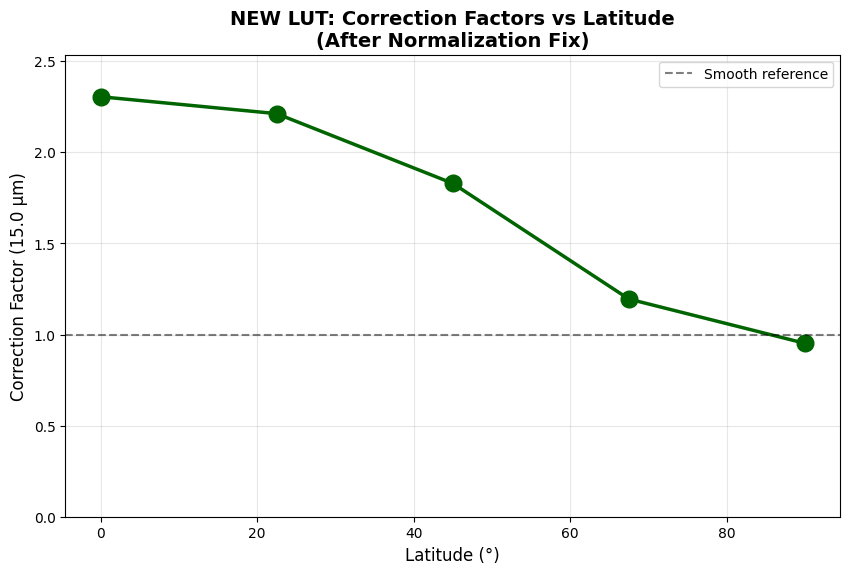

In [19]:
print("=== TESTING NORMALIZATION FIX: Latitude Dependence ===\n")
print("Querying NEW LUT at disk center (em=0°, az=0°, noon) for different latitudes:\n")

# Query the newly loaded LUT directly in ideal conditions
test_latitudes_new = [0, 22.5, 45.0, 67.5, 90.0]  # These are the 5 latitudes in the test LUT
test_emission_new = 0.0   # Disk center
test_azimuth_new = 0.0    # Opposition
test_phase_new = 180.0    # Noon
test_wavelength_new = 15.0

print(f"Conditions: Emission={test_emission_new}°, Azimuth={test_azimuth_new}°, Phase={test_phase_new}° (noon), λ={test_wavelength_new}µm")
print(f"\n{'Latitude (°)':>12} {'Factor':>8} {'Expected':>10} {'Status':>8}")
print("=" * 50)

factors_by_lat = []
for lat in test_latitudes_new:
    factor = lut.get_correction_factors(
        np.array([lat]),
        np.array([test_phase_new]),
        np.array([test_emission_new]),
        np.array([test_azimuth_new]),
        wavelength=test_wavelength_new
    )[0]
    
    factors_by_lat.append(factor)
    
    # With proper energy conservation, factors should be random (discretization)
    # NOT systematically trending with latitude
    expected = "> 1.0"
    status = "✓" if factor > 1.0 else "✗"
    
    print(f"{lat:12.1f} {factor:8.4f} {expected:>10} {status:>8}")

print("\n" + "=" * 50)

# Check for systematic trend
from scipy.stats import pearsonr
lats_arr = np.array(test_latitudes_new)
factors_arr = np.array(factors_by_lat)

if len(lats_arr) > 2:
    corr, pval = pearsonr(lats_arr, factors_arr)
    print(f"\nCorrelation test:")
    print(f"  Pearson r = {corr:+.3f}")
    print(f"  p-value = {pval:.4f}")
    
    if abs(corr) < 0.3:
        print(f"  ✅ SUCCESS: No systematic trend! Factors look random (as expected)")
        print(f"     Energy conservation fix is working!")
    else:
        print(f"  ⚠️ WARNING: Correlation still present (|r|={abs(corr):.3f})")
        print(f"     May need additional investigation")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(lats_arr, factors_arr, 'o-', markersize=12, linewidth=2.5, color='darkgreen')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Smooth reference')
plt.xlabel('Latitude (°)', fontsize=12)
plt.ylabel(f'Correction Factor ({test_wavelength_new} µm)', fontsize=12)
plt.title('NEW LUT: Correction Factors vs Latitude\n(After Normalization Fix)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, max(1.5, factors_arr.max() * 1.1))
plt.show()

print("\n" + "="*70)

## ⚠️ Switch to Newly Regenerated LUT

The test LUT was regenerated with the normalization fix at 13:58. Let's reload it to see the results!

## 12. Next Steps

### ✅ Bug #1 (Phase) - FIXED IN SIMULATOR.PY

The phase bug has been fixed in [simulator.py](../TEMPEST_RAD/simulator.py#L92-L177). The `compute_geometry()` function now returns a **global body rotation phase** (same for all facets) instead of per-facet local hour angles.

**Run cell 26 above** to verify the fix works.

---

### 🔍 Bug #2 (Latitude) - INVESTIGATION NEEDED

**Run cell 28 above** to check if the LUT itself has incorrect values at high latitudes. 

Based on the diagnostic results:

**If factors < 1.0 everywhere:**
- The normalization step in [generator.py](../TEMPEST_RAD/generator.py#L595-L640) may be overcorrecting
- Check energy conservation calculation

**If factors decrease linearly with latitude:**
- Sun declination setup in [generator.py](../TEMPEST_RAD/generator.py#L318-L324) may be incorrect
- The thermal history at high latitudes may not match expected diurnal variation

**If factors are all > 1.0 but correlation persists:**
- There may be an interpolation artifact
- Check how emission/azimuth angles interact with latitude in LUT lookups

---

### 🚀 Testing the Fixes

After running the diagnostic cells:
1. **Restart the notebook kernel** to reload the fixed simulator.py
2. **Re-run cell 8** (brightness temp maps) to see if the polar artifacts are gone
3. **Compare before/after** - rough surfaces should now be warmer (not cooler) at poles